<a href="https://colab.research.google.com/github/jaydenjung-bohs09/jaydenjung-bohs09.github.io/blob/main/Copy_of_Protein_Sequence_Regression_Beginner_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color=darkblue size=6>**Protein Sequence Regression:** Our First Workshop!</font>

---

Welcome to ESAP 2026 GenAI for biology! In this workshop, you will use Python to answer a biological question:

> **Can we use a protein's amino-acid sequence to predict a numerical property?**

By the end, you will have built and evaluated your own **regression model**. (A type of *predictive* model)

### What you will learn

1. How to work in Google Colab
2. A few Python basics
3. How to use `numpy`, `pandas`, and `matplotlib`
4. How computers represent protein sequences as numbers
5. How to create a Hugging Face `Dataset`
6. How to train and evaluate a regression model
* Model architecture: [**Random Forest Regressor**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
* Evaluation Metrics: [**R²**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html), [**Root Mean Squared Error (RMSE)**](https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.root_mean_squared_error.html), [**Mean Absolute Error (MAE)**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html)

### Note on dataset

In this workbook, we will have you create biologically plausible, yet random data. We will utilize a real dataset in the next Workbook (tomorrow).



<font color = red>The notebook contains 📌 Your turn! prompts which ask you to complete independent activities.</font>

# <font color=darkblue>**Part 0.a** Getting Comfortable with Google Colab</font>

ALL students should heed this warning:

---

<font color=red>**DO NOT simply close out a window when you are done running code.** You will waste your compute units and the $50 you spent on Pro+! You must go to `Runtime` -> `Disconnect and delete runtime`

---

Google Colab is an online notebook. A notebook contains two main kinds of cells:

* **Text cells**, like this one, contain explanations.
* **Code cells** contain Python instructions that the computer can run.

To run a code cell:

1. Click the cell.
2. Press the triangular **play** button on its left, or press **Shift + Enter**.
3. Wait for the result to appear below it.

Run the next cell now.

In [ ]:
print("Hello, ESAP Students!")

Hello, ESAP Students!


When a cell finishes, Colab remembers the variables it created. This means one cell can use information produced by an earlier cell.

Run the next two cells **in order**.

In [ ]:
number_of_students = 28

In [ ]:
print("There are", number_of_students, "students in this workshop.")

There are 28 students in this workshop.


## A few useful Colab habits

* Run the notebook from top to bottom.
* A number such as `[3]` beside a cell means it was the third code cell run in the current session.
* A spinning icon means the code is still running.
* If variables become mismatched, go to the top menu, choose **Runtime → Restart session**, then run the cells again from the top.
* Your temporary Colab computer disappears after the session, so download anything you want to keep.
* You can insert a **New cell** below your current cell by clicking "+ Text" or "+ Code", above.

<font color=red>📌 **Your turn!** Change the message below so it prints your name.</font>

In [ ]:
my_name = "Jayden"
print("Hello! My name is:", my_name)

Hello! My name is: Jayden


# <font color=darkblue>**Part 0.b** The Runtime</font>

A *runtime* is a virtual machine (VM) provided by Google to run the code in your notebook (`.ipynb` file).

* When you first open a Colab notebook, you will most likely need to *initialize the runtime* yourself by clicking **`Connect`** (top right).
* Once you've connected, you can click next to the <font color=green>green check</font> to see which resources you have available.

## Runtime initialization

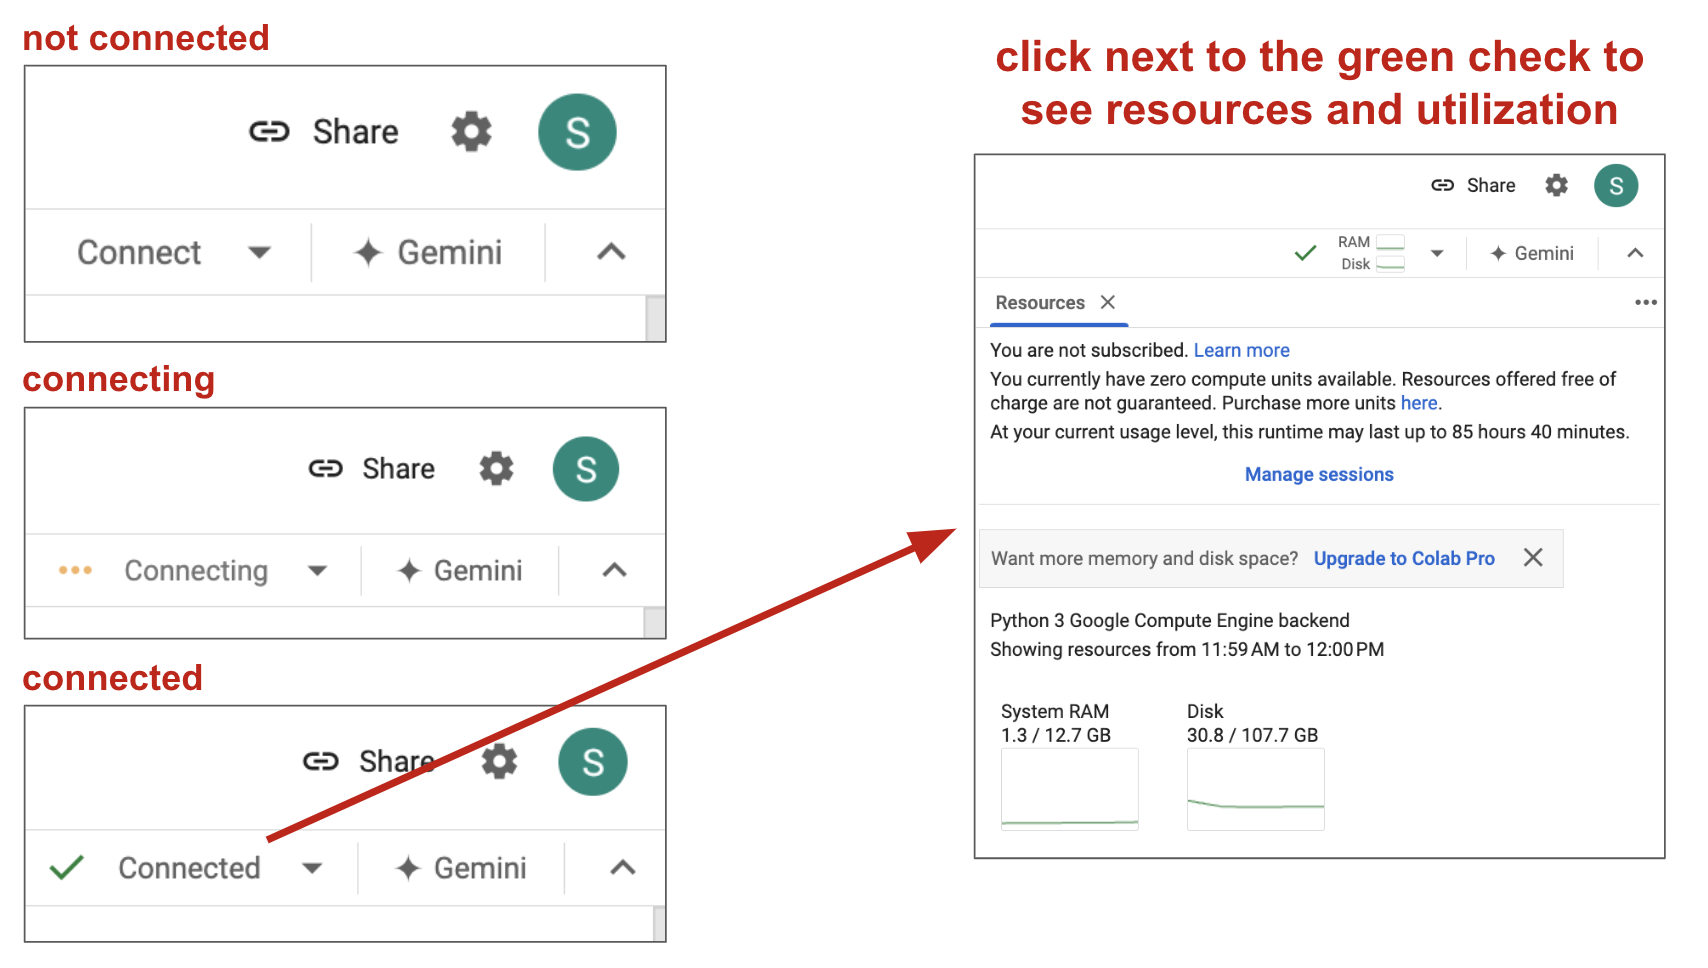

## Changing the runtime type

Navigate to `Runtime` → `Change runtime type` to view your current hardware accelerator (probably CPU) and other options. From here, you can change to a GPU if needed.
* We do not recommend using TPU

* **You will need to subscribe to Colab Pro or Pro+ for faster GPUs, more memory (RAM), and other priviliges like background execution (Pro+ only). If you do upgrade, A100 is your best GPU option, followed by L4, then T4.**

## Resetting the runtime

Sometimes, something goes wrong in a runtime. Perhaps you installed the wrong package versions, your runtime failed, or you got CUDA out of memory errors, and you want to completely start over. Or, you may just want to clear outputs so the notebook looks clean again.

In the top menu, you can use these functions to delete/reset progress according to your needs.

1. `Runtime` -> `Restart session`: restarts the Python environment while keeping the runtime connected and resources engaged. Deletes in-memory variables, loaded modules, and temporary states. Use this option when:
  * **Debugging or cleanup**: if your notebook crashes, starts behaving unpredictably, or you suspect memory leaks
  * **Reimports needed**: after you change code in a way that requires re-importing packages/modules
  * **Out of Memory (OOM) errors**: this will free up your memory again
  * **Fresh execution**: to restart from the top of the notebook without reconnecting
2. `Runtime` -> `Disconnect and delete runtime` : to delete everything you've done in this runtime and start over. This deletes all variables, uninstalls and unimports all packages, and disconnects all resources. But <font color=darkred>you may lose access to premium GPUs when you reconnect to a new runtime.</font> Use this option when:
  * **Switching machine types**: CPU -> GPU, or one GPU type to another
  * **Long term inactivity**: when you're done with the session and want to ensure you free up your allocated GPU, to avoid wasting compute units when you aren't using them.
  * **Persistent runtime issues**: if `Restart session` doesn't fix an issue
  * **Clean runtime allocation**: if you suspect the runtime itself (e.g. the backend virtual machine) is causing issues.
3. `Edit` -> `Clear all outputs`: clear the printed outputs underneath the notebook cells. Does not delete any variables, or uninstall/unimport any packages.

# <font color=darkblue>**Part 0.c** Imports and installs</font>

Installing and importing packages is an essential part of writing code! You definitely don't want to write everything from scratch.

The **!** symbol allows run commands outside of python, usually bash commands that update packages, install new packages, or download files.

First, we will import a number of important packages/modules within packages.
* [pandas](https://pandas.pydata.org): an essential data analysis tool
* [numpy](https://numpy.org): scientific computing package
* [seaborn](https://seaborn.pydata.org): statistical data visualization
* [matplotlib.pyplot](https://matplotlib.org): plotting and visualization
* [torch](https://pypi.org/project/torch/): PyTorch, needed in this notebook to run esm
* [pickle](https://docs.python.org/3/library/pickle.html): package for reading .pkl files, which are efficient files for storing data structures like dictionaries.
* [json](https://www.w3schools.com/python/python_json.asp): package for working with json data
* and all the modules we need from `sklearn`.

When we `import [package] as [abbrev]`, that means we can call the package by the abbreviation we've chosen in our code. For example, since we've done `import pandas as pd`, instead of saying `pandas.read_csv()`, we will write `pd.read_csv()`.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import pickle
import json

In the next cell, we'll use [**`pip`**](https://pip.pypa.io/en/stable/), the standard package installer for Python, to install a number of packages, and then we will `import` the packages or modules from them.
* [transformers](https://pypi.org/project/transformers/): allows you to use NLP models called Transformers through HuggingFace, a platform for building, deploying, and training machine learning models. Today we will simply use it for making our Dataset.
* [scikit-learn](https://scikit-learn.org/stable/): the one-stop shop for machine learning!

In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, ParameterGrid, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder

This package allows us to efficiently deliver our data to a machine learning algorithm.

In [ ]:
!pip -q install datasets

<font color=red>📌 **Your turn!** import the "Dataset" package from the "datasets" library below. (Hint: see the cell above for the correct syntax!)

In [ ]:
from datasets import Dataset

# <font color=darkblue>**Part 1.** Python and NumPy Basics</font>

Python stores information in **variables**. Different kinds of information have different **data types**.

In [ ]:
protein_name = "Demo protein"      # string: text
sequence_length = 120              # integer: whole number
stability_score = 63.5             # float: decimal number
is_reviewed = True                 # Boolean: True or False

print(type(protein_name))
print(type(sequence_length))
print(type(stability_score))
print(type(is_reviewed))

<class 'str'>
<class 'int'>
<class 'float'>
<class 'bool'>


## Lists and indexing

A **list** stores several items in order. Python starts counting positions at **0**, not 1. The **final** position can be accessed with [-1]

In [ ]:
amino_acids = ["A", "C", "D", "E", "F"]

print("The full list:", amino_acids)
print("First item:", amino_acids[0])
print("Third item:", amino_acids[2])
print("Number of items:", len(amino_acids))

The full list: ['A', 'C', 'D', 'E', 'F']
First item: A
Third item: D
Number of items: 5


<font color=red>📌 **Your turn!** Predict the output before running the next cell.</font>

In [ ]:
short_sequence = "ACDEFG"
print(short_sequence[0])
print(short_sequence[-1])
print(len(short_sequence))

A
G
6


## NumPy: working with arrays of numbers

[`numpy`](https://numpy.org/) is a Python library for numerical data. We usually import it using the nickname `np`.

A NumPy **array** is similar to a list, but it is designed for efficient mathematical operations.

In [ ]:
scores = np.array([45.0, 52.5, 61.0, 68.5, 73.0])

print("Scores:", scores)
print("Mean:", scores.mean())
print("Minimum:", scores.min())
print("Maximum:", scores.max())

Scores: [45.  52.5 61.  68.5 73. ]
Mean: 60.0
Minimum: 45.0
Maximum: 73.0


NumPy can perform one operation on every value at once. This is called **vectorized computation**. This is *very valuable* for data processing!

In [ ]:
print("Original scores:", scores)
print("Scores plus 5:", scores + 5)
print("Scores divided by 10:", scores / 10)

Original scores: [45.  52.5 61.  68.5 73. ]
Scores plus 5: [50.  57.5 66.  73.5 78. ]
Scores divided by 10: [4.5  5.25 6.1  6.85 7.3 ]


## Two-dimensional arrays

A two-dimensional array is a grid with **rows** and **columns**. Its `.shape` reports:

`(number of rows, number of columns)`

In [ ]:
example_matrix = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
    [1, 0, 0],
])

print(example_matrix)
print("Shape:", example_matrix.shape)

[[1 0 0]
 [0 1 0]
 [0 0 1]
 [1 0 0]]
Shape: (4, 3)


<font color=red>📌 **Your turn!** Add one more row to `example_matrix`. What happens to its shape?</font>

# <font color=darkblue>**Part 2.** pandas and Protein Data</font>


`pandas` revolves around two objects: the **`Series`** and the **`DataFrame`**.
* **`Series`**: a column of data.
  * A Series is a 1D labeled array capable of holding any data type (integers, strings, floating point numbers, Python objects, etc.).
  * The axis labels are collectively referred to as the index
* **`DataFrame`**: the full data table.
  * A DataFrame is a 2D labeled data structure with columns of potentially different types (*e.g.* one integer column, one string column, etc.)
  * The axis labels are collectively referred to as the index
  * Think of it like a *spreadsheet* or SQL table, or a dict of Series objects. **Each column of a DataFrame is a Series**.
  * It is the most commonly used pandas object.

In this section, we'll teach you all the absolute essentials for working with `Series` and `DataFrame`.

For more info, see the <a target="_blank" href="https://pandas.pydata.org/docs/user_guide/dsintro.html#dsintro">Intro to data structures</a> section in the pandas documentation.

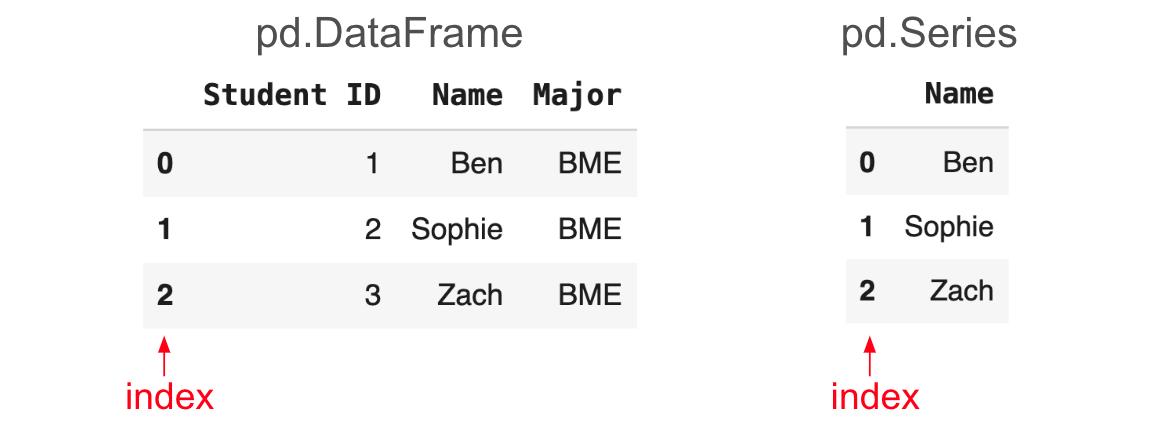

### **Creation of Series!**
The simplest way to create a <a target="_blank" href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series">`Series`</a> is by passing a list of values, letting pandas create a default integer index:
* *Tip*: use the `display()` function to get a pretty view of your Series.

In [ ]:
s = pd.Series([1, 3, 5, np.nan, 6, 8]) # np.nan represents a Null value. nan = not a number

display(s)

,0
0,1.0
1,3.0
2,5.0
3,NaN
4,6.0
5,8.0


### **Understanding the Data**
A Series can have many thousands of datapoints, and it's important for you to have a good understanding of what's there. A few handy functions will really transform your data processing pipeline.

To understand these functions, let's take an example where we have a Series of **1000 orders at a restaurant**.

1. **`pd.Series.unique()`**: extracts all the *unique* entries in this series, e.g. all the different things that have been ordered.
2. **`pd.Series.value_counts()`**: extracts the number of occurrences of each unique entry, e.g. how many times each menu item was ordered.
3. **`.any()`**: tells you if a condition is satisfied ANY times in the Series, e.g. if ANY entries are equal to "🍕pizza"
4. **`.all()`**: tells you if a condition is at EVERY element in the Series, e.g. if ALL entries are equal to "🍕pizza"

In [ ]:
np.random.seed(0)
menu = ["🍕pizza","🌮tacos","🥗salad"]
orders = pd.Series(np.random.choice(menu, 400))

display(orders)

,0
0,🍕pizza
1,🌮tacos
2,🍕pizza
3,🌮tacos
4,🌮tacos
...,...
395,🥗salad
396,🍕pizza
397,🍕pizza
398,🍕pizza


### **Creating a new DataFrame!**
There are many ways to create a <a target="_blank" href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame">`DataFrame`</a>. It's completely your choice - do whatever feels easiest to you!

One simple way is feeding a **dictionary** into `pd.DataFrame`.

In [ ]:
restaurant = pd.DataFrame(data={
    'Customer': ['Liz','Mike','Brad','Sandy'],
    'Order': ['pizza','pizza','tacos','salad'],
    'Order Number': [1, 2, 3, 4],
    'Price': [5.50, 5.50, 6.20, 7.00],
})
display(restaurant)

,Customer,Order,Order Number,Price
0,Liz,pizza,1,5.5
1,Mike,pizza,2,5.5
2,Brad,tacos,3,6.2
3,Sandy,salad,4,7.0


Similarly, we can use `pd.DataFrame.from_dict()`, and use the `orient=` parameter to decide whether our data should go in as rows or columns.
  * `orient=index` --> the keys will be the indexes of your dataframe, and the values will be rows
  * `orient=columns` --> the keys will be the column names of your dataframe, and the values will be columns

In [ ]:
data={
    'Customer': ['Liz','Mike','Brad','Sandy'],
    'Order': ['pizza','pizza','tacos','salad'],
    'Order Number': [1, 2, 3, 4],
    'Price': [5.50, 5.50, 6.20, 7.00],
}
print("\nSetting orient=columns")
display(pd.DataFrame.from_dict(data, orient='columns'))

print("Setting orient=index")
display(pd.DataFrame.from_dict(data, orient='index'))


Setting orient=columns


,Customer,Order,Order Number,Price
0,Liz,pizza,1,5.5
1,Mike,pizza,2,5.5
2,Brad,tacos,3,6.2
3,Sandy,salad,4,7.0


Setting orient=index


,0,1,2,3
Customer,Liz,Mike,Brad,Sandy
Order,pizza,pizza,tacos,salad
Order Number,1,2,3,4
Price,5.5,5.5,6.2,7.0


### **Writing and loading data**

Two of the most important skills for this class are (1) **loading data** from a file into a DataFrame and (2) **writing data** from a DataFrame into a file.
  * Using [`pd.read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html), we can read all kinds of text files (`.csv`, `.tsv`, `.txt`, etc...) into the convenient DataType object.
  * Using [`DataFrame.to_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html#pandas.DataFrame.to_csv), we can write all kinds of text files (`.csv`, `.tsv`, `.txt`, etc...)
    * <font color=red>**NOTE**: files that you write during a Colab session will DISAPPEAR if you restart/disconnect the session or close the window! You should either (1) mount your drive and save to a path that starts with `/content/drive/MyDrive/...` or (2) download files to your computer before exiting the session.</font>

In [ ]:
dates = pd.date_range("20250101", periods = 6)
df = pd.DataFrame(np.random.randn(6, 4), index = dates, columns = list("ABCD")) # the index is the row label and the columns are the columns labels.
display(df)

,A,B,C,D
2025-01-01,0.521988,1.197260,-0.382486,0.691662
2025-01-02,0.353885,1.047585,-0.423896,-3.514768
2025-01-03,-1.343157,1.425506,0.228582,-0.257664
2025-01-04,0.050371,-1.380211,-0.261672,-0.179380
2025-01-05,-0.692771,1.137827,-0.169157,-0.763914
2025-01-06,-0.498073,-0.362891,0.263960,-0.629642


#### CSV

Let's write our DataFrame.

In [ ]:
# write our data to a .csv file
# if we don't specify a directory, it will save to '/content/', which is on the left side of the screen in the Files section
df.to_csv("foo.csv")

We should see our DataFrame `foo.csv` listed in the `/content` directory (this is where Colab automatically saves files).

In [ ]:
!ls /content

foo.csv  sample_data


In [ ]:
# read it back
print("Reading foo.csv WITHOUT specifying an index column:")
display(pd.read_csv("foo.csv"))

print("Reading foo.csv and specifying an index column:")
display(pd.read_csv("foo.csv", index_col=0)) # Tell pandas that the first column (which it automatically names with the integer 0) is the index

Reading foo.csv WITHOUT specifying an index column:


,Unnamed: 0,A,B,C,D
0,2025-01-01,0.521988,1.197260,-0.382486,0.691662
1,2025-01-02,0.353885,1.047585,-0.423896,-3.514768
2,2025-01-03,-1.343157,1.425506,0.228582,-0.257664
3,2025-01-04,0.050371,-1.380211,-0.261672,-0.179380
4,2025-01-05,-0.692771,1.137827,-0.169157,-0.763914
5,2025-01-06,-0.498073,-0.362891,0.263960,-0.629642


Reading foo.csv and specifying an index column:


,A,B,C,D
2025-01-01,0.521988,1.197260,-0.382486,0.691662
2025-01-02,0.353885,1.047585,-0.423896,-3.514768
2025-01-03,-1.343157,1.425506,0.228582,-0.257664
2025-01-04,0.050371,-1.380211,-0.261672,-0.179380
2025-01-05,-0.692771,1.137827,-0.169157,-0.763914
2025-01-06,-0.498073,-0.362891,0.263960,-0.629642


To ensure this written file isn't lost, we could mount our Drive and write to a folder inside our Drive, instead of writing to `/content`

In [ ]:
# Mount
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# make a directory to save the file in
import os
file_path = '/content/drive/MyDrive/BME590_pandas_tutorial'
os.makedirs(file_path,exist_ok=True)

# Example
df.to_csv(f"{file_path}/foo.csv")

# look what's in this folder
!ls {file_path}

foo.csv


## Now for a more advanced exercise!

Below we are creating a dataframe of protein data by making each *row* independently, joining them all into a dict, then coercing that into a dataframe. You will see some **more advanced syntax** in this section -- read the docstrings in each function!

We also introduce you to some terminology about proteins in this section --
* Amino acid: the individual building blocks (molecules) of proteins
* Hydrophobic: A water-hating molecule
* Charged: A molecule that carries a positive or negative charge
* Aromatic: A molecule that has a ["simple aromatic"](https://en.wikipedia.org/wiki/Simple_aromatic_ring) ring
* Flexible: Amino acids that add flexibility into protein structures

In [ ]:
# These are the 20 standard amino-acid letters.
AA = np.array(list("ACDEFGHIKLMNPQRSTVWY"))

# Amino acid probabilities, loosely inspired by typical protein composition.
aa_probabilities = np.array([
    0.082, 0.014, 0.055, 0.067, 0.039,
    0.071, 0.023, 0.059, 0.096, 0.097,
    0.024, 0.041, 0.047, 0.039, 0.055,
    0.066, 0.053, 0.069, 0.011, 0.029
])
aa_probabilities = aa_probabilities / aa_probabilities.sum()

rng = np.random.default_rng(42)

def make_sequence(length):
    """
    Create one random protein-like amino-acid sequence.

    "".join combines a list into a string with no separation
    "X".join(["A", "B", "C"]) → "A.B.C"
    """
    return "".join(rng.choice(AA, size=length, p=aa_probabilities))

def fraction(sequence, letters):
    """
    Calculate the proportion of a protein that belongs to
    each amino acid group.

    sequence: a string
    letters: a set of amino acids (no repeats allowed!)
    """
    return sum(letter in letters for letter in sequence) / len(sequence)

rows = []
for protein_id in range(1, 301):
    length = int(rng.integers(60, 221))
    sequence = make_sequence(length)

    # Notice coersion into a set
    # These are the amino acid groups!
    hydrophobic = fraction(sequence, set("AILMFWVY"))
    charged = fraction(sequence, set("DEKR"))
    aromatic = fraction(sequence, set("FWY"))
    flexible = fraction(sequence, set("GP"))

    # Make up a simple "stability" score for the entire protein
    score = (
        45
        + 45 * hydrophobic
        + 18 * charged
        + 25 * aromatic
        - 20 * flexible
        + 0.025 * length
        + rng.normal(0, 2.5)
    )

    rows.append({
        "protein_id": f"protein_{protein_id:03d}",
        "sequence": sequence,
        "stability_score": round(float(score), 2),
    })

data = pd.DataFrame(rows)
data.to_csv("protein_regression_demo.csv", index=False)

print("Created protein_regression_demo.csv")
print("Number of proteins:", len(data))

Created protein_regression_demo.csv
Number of proteins: 300


NOTE: If the "fraction" function is confusiong, check this cell below!

In [ ]:
my_sequence = "BANANA"
my_letters = set("AEIOU") # (Sometimes y?)

# Let's trace it:
# For 'B', 'B' in my_letters is False (0)
# For 'A', 'A' in my_letters is True (1)
# For 'N', 'N' in my_letters is False (0)
# For 'A', 'A' in my_letters is True (1)
# For 'N', 'N' in my_letters is False (0)
# For 'A', 'A' in my_letters is True (1)

# The sum will be 0 + 1 + 0 + 1 + 0 + 1 = 3
# len(my_sequence) is 6
# So, the result will be 3 / 6 = 0.5

result = sum(letter in my_letters for letter in my_sequence) / len(my_sequence)
print(f"Sequence: {my_sequence}")
print(f"Letters to check for: {my_letters}")
print(f"Fraction of matching letters: {result}")


Sequence: BANANA
Letters to check for: {'I', 'A', 'O', 'E', 'U'}
Fraction of matching letters: 0.5


## Understanding the table

Each row represents one protein.

* `protein_id`: a unique name
* `sequence`: the amino-acid sequence
* `stability_score`: the numerical value we will predict

Useful pandas commands include:

* `data.head()` — first five rows
* `data.shape` — number of rows and columns
* `data.columns` — column names
* `data.info()` — data types and missing values
* `data.describe()` — summary statistics for numerical columns

In [ ]:
print("Table shape:", data.shape)
print("Column names:", list(data.columns))
print()
data.info()

Table shape: (300, 3)
Column names: ['protein_id', 'sequence', 'stability_score']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   protein_id       300 non-null    object 
 1   sequence         300 non-null    object 
 2   stability_score  300 non-null    float64
dtypes: float64(1), object(2)
memory usage: 7.2+ KB


In [ ]:
display(data.describe())

,stability_score
count,300.000000
mean,70.563133
std,3.337899
min,58.740000
25%,68.627500
50%,70.425000
75%,72.895000
max,79.470000


## Selecting rows and columns

A single pair of square brackets selects a column.

In [ ]:
score_column = data["stability_score"]
print(score_column.head())

0    68.00
1    70.58
2    70.05
3    73.23
4    71.18
Name: stability_score, dtype: float64


`.iloc` selects rows and columns by their numbered position.

In [ ]:
print("First protein ID:", data.iloc[0, 0])
print("First sequence:", data.iloc[0, 1])
print("First score:", data.iloc[0, 2])

First protein ID: protein_001
First sequence: KTQDYRSDKIVNSKFLASNRIWTREKAEPRWHIKEDKFPKSQGSSIGPDEASPQSKLDDPKLRNLLGAKFKTFA
First score: 68.0


## Creating a new column

Protein length is the number of amino acids in a sequence. We can calculate it with `len` and **apply** that function to every sequence.

In [ ]:
data["sequence_length"] = data["sequence"].apply(len)

display(data.head())

,protein_id,sequence,stability_score,sequence_length
0,protein_001,KTQDYRSDKIVNSKFLASNRIWTREKAEPRWHIKEDKFPKSQGSSI...,68.00,74
1,protein_002,GPLSPKSEACQKELEQKIGNICDWVQGWRQKGDVKEGLETRQKNMP...,70.58,184
2,protein_003,GDVEGEDAAEAMPIHLTTAEFGLKAILDSAVDSVYSRNRDLLTKIN...,70.05,90
3,protein_004,LKLRSLMVDDCPKRPHVRGIGEEVKIRLVSKIYQVDTNDMPAKSGK...,73.23,192
4,protein_005,CRKKEEVAFGLMLCFSNPPRAILHTKRTLVMTILLDKVNEIEAVKG...,71.18,195


## Filtering rows

The next command keeps only proteins longer than 180 amino acids.

In [ ]:
long_proteins = data[data["sequence_length"] > 180]

print("Number of long proteins:", len(long_proteins))
display(long_proteins.head())

Number of long proteins: 73


,protein_id,sequence,stability_score,sequence_length
1,protein_002,GPLSPKSEACQKELEQKIGNICDWVQGWRQKGDVKEGLETRQKNMP...,70.58,184
3,protein_004,LKLRSLMVDDCPKRPHVRGIGEEVKIRLVSKIYQVDTNDMPAKSGK...,73.23,192
4,protein_005,CRKKEEVAFGLMLCFSNPPRAILHTKRTLVMTILLDKVNEIEAVKG...,71.18,195
6,protein_007,DERAYIQTIHNLKMVKEIIDEPIVFDRTGEELKGAKVPLDGGRTVY...,71.71,198
7,protein_008,PAKTNKVTHLLNHFVVSYRRRKKFPGGMKFSTEAHSSDRDIYEEKN...,73.63,188


<font color=red>📌 **Your turn!** Instead of splitting on sequence_length, split on stability_score (choose your own cutoff!) How does this change the shape of the dataframe?</font>

## Quick data-quality checks

The dataframe above is the dataset you will use to train your first model! We will be predicting the `stability_score` of each protein.

Our first problem is **regression**: the outputs are continuous numerical values, not discrete classes or categories (that would instead be classification).

Before training any model, we should check for missing values, duplicate sequences, and invalid amino-acid letters.

In [ ]:
valid_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")

def is_valid_sequence(sequence):
    return set(sequence).issubset(valid_amino_acids)

print("Missing values in each column:")
print(data.isna().sum())
print()
print("Duplicate sequences:", data["sequence"].duplicated().sum())
print("Invalid sequences:", (~data["sequence"].apply(is_valid_sequence)).sum())

Missing values in each column:
protein_id         0
sequence           0
stability_score    0
sequence_length    0
dtype: int64

Duplicate sequences: 0
Invalid sequences: 0


# <font color=darkblue>**Part 3.** Plotting with matplotlib</font>

A plot helps us see patterns that may be difficult to notice in a table.

[`matplotlib`](https://matplotlib.org/) is the most common basic plotting library in Python. We usually import its plotting module as `plt`.

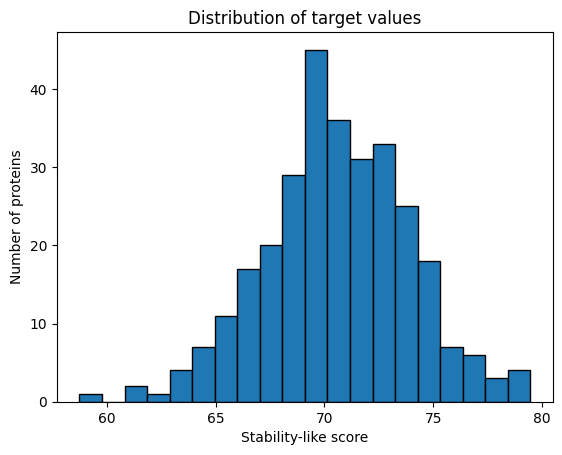

In [ ]:
plt.hist(data["stability_score"], bins=20, edgecolor="black")
plt.xlabel("Stability-like score")
plt.ylabel("Number of proteins")
plt.title("Distribution of target values")
plt.show()

This histogram shows how frequently different target values occur.

<font color=red>📌 **Your turn!** Play around with the number of bins! What changes, and what stays the same?</font>

## Scatter plot

A scatter plot places one point for each protein. Let us compare sequence length with the stability score.

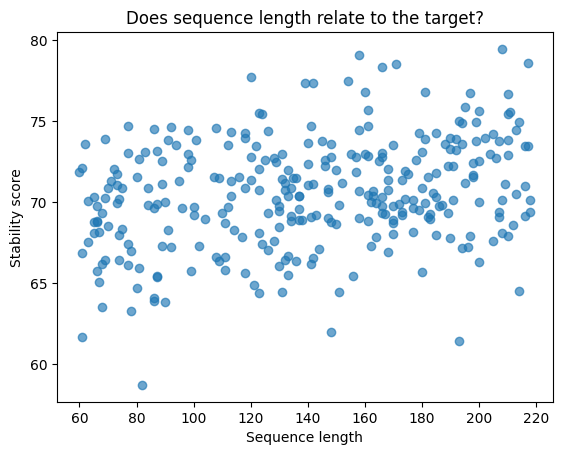

In [ ]:
plt.scatter(data["sequence_length"], data["stability_score"], alpha=0.65)
plt.xlabel("Sequence length")
plt.ylabel("Stability score")
plt.title("Does sequence length relate to the target?")
plt.show()

A visible trend would suggest that length contains useful predictive information. A cloud with no pattern would suggest a weak relationship.

We can calculate the **correlation** as a quick numerical summary. Values near `1` indicate a strong positive relationship, values near `-1` indicate a strong negative relationship, and values near `0` indicate little linear relationship.

In [ ]:
correlation = data["sequence_length"].corr(data["stability_score"])
print("Correlation:", round(correlation, 3))

Correlation: 0.287


# <font color=darkblue>**Part 4.** Turning Protein Sequences into Numbers</font>

Although we are predicting `stability_score` based upon the protein's sequence, a machine-learning model cannot directly understand a string such as:

`MKTLLV...`

We must convert each sequence into numerical **features**. This process is often called **encoding**, **featurization**, or **embedding**.

We will compare two representations:

1. **One-hot amino-acid composition** — counts how often each amino acid appears.
2. **VHSE descriptors** — represents amino acids using eight physicochemical descriptor values.

## <font size=5>4.1 One-hot encoding</font>

For one amino acid, one-hot encoding creates a vector with one `1` and the rest `0`.

For a tiny alphabet `[A, C, D]`:

* `A → [1, 0, 0]`
* `C → [0, 1, 0]`
* `D → [0, 0, 1]`

For proteins, we use all 20 standard amino acids.

In [ ]:
amino_acid_order = list("ACDEFGHIKLMNPQRSTVWY")

def one_hot_matrix(sequence):
    """Return a matrix with one row per residue and one column per amino acid."""
    matrix = np.zeros((len(sequence), len(amino_acid_order)), dtype=int)
    aa_to_column = {aa: i for i, aa in enumerate(amino_acid_order)}

    for row, aa in enumerate(sequence):
        matrix[row, aa_to_column[aa]] = 1

    return matrix

example_sequence = "ACDA"
example_one_hot = one_hot_matrix(example_sequence)

print("Sequence:", example_sequence)
print("Amino-acid order:", amino_acid_order)
print(example_one_hot)
print("Shape:", example_one_hot.shape)

Sequence: ACDA
Amino-acid order: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
Shape: (4, 20)


Each row represents one residue. Because proteins have different lengths, these matrices have different numbers of rows.

For this first model, we will average down the rows. The resulting 20 values are the **fraction of each amino acid** in the sequence.

In [ ]:
def one_hot_composition(sequence):
    return one_hot_matrix(sequence).mean(axis=0)

example_composition = one_hot_composition(example_sequence)

print("Composition vector:")
print(example_composition)
print("Vector length:", len(example_composition))
print("Sum of fractions:", example_composition.sum())

Composition vector:
[0.5  0.25 0.25 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.  ]
Vector length: 20
Sum of fractions: 1.0


<font color=red>📌 **Your turn!** For `ACDA`, which amino acid has the largest fraction? Why?</font>

In [ ]:
# Encode every sequence in the table.
one_hot_features = np.vstack(data["sequence"].apply(one_hot_composition))

print("Feature matrix shape:", one_hot_features.shape)
print("Rows = proteins; columns = amino-acid fractions")

Feature matrix shape: (300, 20)
Rows = proteins; columns = amino-acid fractions


## <font size=5>4.2 VHSE descriptors</font>

One-hot encoding treats amino acids only as different identities. However, amino acids also have chemical and physical properties. (Remember the four "gropus" we introduced earlier: Hydrophobic, Charged, Aromatic, and Flexible)

**VHSE** stands for **Vectors of Hydrophobic, Steric, and Electronic properties**. Each amino acid is represented by eight values summarizing correlated physicochemical properties.

The exact meaning of an individual VHSE dimension is less intuitive than “fraction of alanine.” However, the representation is useful because it compresses related amino-acid properties into only eight dimensions.

In [ ]:
VHSE = {
    "A": [ 0.15, -1.11, -1.35, -0.92,  0.02, -0.91,  0.36, -0.48],
    "R": [-1.47,  1.45,  1.24,  1.27,  1.55,  1.47,  1.30,  0.83],
    "N": [-0.99,  0.00, -0.37,  0.69, -0.55,  0.85,  0.73, -0.80],
    "D": [-1.15,  0.67, -0.41, -0.01, -2.68,  1.31,  0.03,  0.56],
    "C": [ 0.18, -1.67, -0.46, -0.21,  0.00,  1.20, -1.61, -0.19],
    "Q": [-0.96,  0.12,  0.18,  0.16,  0.09,  0.42, -0.20, -0.41],
    "E": [-1.18,  0.40,  0.10,  0.36, -2.16, -0.17,  0.91,  0.02],
    "G": [-0.20, -1.53, -2.63,  2.28, -0.53, -1.18,  2.01, -1.34],
    "H": [-0.43, -0.25,  0.37,  0.19,  0.51,  1.28,  0.93,  0.65],
    "I": [ 1.27, -0.14,  0.30, -1.80,  0.30, -1.61, -0.16, -0.13],
    "L": [ 1.36,  0.07,  0.26, -0.80,  0.22, -1.37,  0.08, -0.62],
    "K": [-1.17,  0.70,  0.70,  0.80,  1.64,  0.67,  1.63,  0.13],
    "M": [ 1.01, -0.53,  0.43,  0.00,  0.23,  0.10, -0.86, -0.68],
    "F": [ 1.52,  0.61,  0.96, -0.16,  0.25,  0.28, -1.33, -0.20],
    "P": [ 0.22, -0.17, -0.50,  0.05, -0.01, -1.34, -0.19,  3.56],
    "S": [-0.67, -0.86, -1.07, -0.41, -0.32,  0.27, -0.64,  0.11],
    "T": [-0.34, -0.51, -0.55, -1.06, -0.06, -0.01, -0.79,  0.39],
    "W": [ 1.50,  2.06,  1.79,  0.75,  0.75, -0.13, -1.01, -0.85],
    "Y": [ 0.61,  1.60,  1.17,  0.73,  0.53,  0.25, -0.96, -0.52],
    "V": [ 0.76, -0.92, -0.17, -1.91,  0.22, -1.40, -0.24, -0.03],
}

print("Alanine (A):", VHSE["A"])
print("Tryptophan (W):", VHSE["W"])

Alanine (A): [0.15, -1.11, -1.35, -0.92, 0.02, -0.91, 0.36, -0.48]
Tryptophan (W): [1.5, 2.06, 1.79, 0.75, 0.75, -0.13, -1.01, -0.85]


In [ ]:
def vhse_matrix(sequence):
    """Return one 8-value VHSE row for each residue."""
    return np.array([VHSE[aa] for aa in sequence], dtype=float)

def vhse_average(sequence):
    """Average residue-level VHSE values into one 8-value protein vector."""
    return vhse_matrix(sequence).mean(axis=0)

example_vhse = vhse_matrix("ACDA")
print(example_vhse)
print("Residue-level shape:", example_vhse.shape)
print("Protein-level vector:", vhse_average("ACDA"))

[[ 0.15 -1.11 -1.35 -0.92  0.02 -0.91  0.36 -0.48]
 [ 0.18 -1.67 -0.46 -0.21  0.    1.2  -1.61 -0.19]
 [-1.15  0.67 -0.41 -0.01 -2.68  1.31  0.03  0.56]
 [ 0.15 -1.11 -1.35 -0.92  0.02 -0.91  0.36 -0.48]]
Residue-level shape: (4, 8)
Protein-level vector: [-0.1675 -0.805  -0.8925 -0.515  -0.66    0.1725 -0.215  -0.1475]


In [ ]:
vhse_features = np.vstack(data["sequence"].apply(vhse_average))

print("VHSE feature matrix shape:", vhse_features.shape)

VHSE feature matrix shape: (300, 8)


## Adding sequence length

Averaging makes every protein a fixed-size vector, but it removes the original length. Because length may contain useful information, we will add it as one extra feature to both representations.

In [ ]:
length_feature = data[["sequence_length"]].to_numpy()

one_hot_plus_length = np.hstack([one_hot_features, length_feature])
vhse_plus_length = np.hstack([vhse_features, length_feature])

print("One-hot + length shape:", one_hot_plus_length.shape)
print("VHSE + length shape:", vhse_plus_length.shape)

One-hot + length shape: (300, 21)
VHSE + length shape: (300, 9)


<font color=red>📌 **Your turn!** Why do the two feature matrices have different numbers of columns?</font>

<font color=red>**Hint:** one-hot has 20 amino-acid fractions; VHSE has 8 descriptor averages. Both also include sequence length.</font>

# <font color=darkblue>**Part 5.** Hugging Face Dataset and Regression</font>

The [Hugging Face `datasets`](https://huggingface.co/docs/datasets/) library provides a convenient format for storing, transforming, and splitting datasets.

A Hugging Face `Dataset` does **not** automatically train a model. It organizes the examples so they can be used by many machine-learning tools.

In [ ]:
hf_dataset = Dataset.from_pandas(data, preserve_index=False)
hf_dataset

Dataset({
    features: ['protein_id', 'sequence', 'stability_score', 'sequence_length'],
    num_rows: 300
})

We can inspect one example using square brackets.

In [ ]:
first_example = hf_dataset[0]

print("Protein ID:", first_example["protein_id"])
print("Sequence length:", first_example["sequence_length"])
print("Target:", first_example["stability_score"])
print("Beginning of sequence:", first_example["sequence"][:30] + "...")

Protein ID: protein_001
Sequence length: 74
Target: 68.0
Beginning of sequence: KTQDYRSDKIVNSKFLASNRIWTREKAEPR...


## Add embeddings to the Hugging Face Dataset

The `.map()` method applies a function to examples. Here, our function calculates both encodings for each sequence.

In [ ]:
def add_embeddings(example):
    example["one_hot_features"] = one_hot_composition(example["sequence"]).tolist()
    example["vhse_features"] = vhse_average(example["sequence"]).tolist()
    return example

hf_dataset = hf_dataset.map(add_embeddings)
print(hf_dataset.column_names)

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

['protein_id', 'sequence', 'stability_score', 'sequence_length', 'one_hot_features', 'vhse_features']


## Train/test split

A model needs examples for **training**, but it must be evaluated on *different* examples it did not encounter during training.

* **Training set:** used to learn patterns.
* **Test set:** held aside until evaluation.

We will use 80% for training and 20% for testing. The random seed makes the split reproducible.

In general, **random splitting** is not the best strategy for splitting your data as it can lead to *leakage*. Leakage is a term for the inflated capabilities your model can seem to have when it is evaluated on inputs very similar (or identical) to what it encountered during training.

Tomorrow's workbook will employ a different splitting strategy.

In [ ]:
split_dataset = hf_dataset.train_test_split(test_size=0.20, seed=42)

print(split_dataset)
print("Training proteins:", len(split_dataset["train"]))
print("Test proteins:", len(split_dataset["test"]))

DatasetDict({
    train: Dataset({
        features: ['protein_id', 'sequence', 'stability_score', 'sequence_length', 'one_hot_features', 'vhse_features'],
        num_rows: 240
    })
    test: Dataset({
        features: ['protein_id', 'sequence', 'stability_score', 'sequence_length', 'one_hot_features', 'vhse_features'],
        num_rows: 60
    })
})
Training proteins: 240
Test proteins: 60


## What is regression?

**Regression** predicts a continuous numerical value, such as temperature, concentration, binding affinity, or today's `stability_score`.



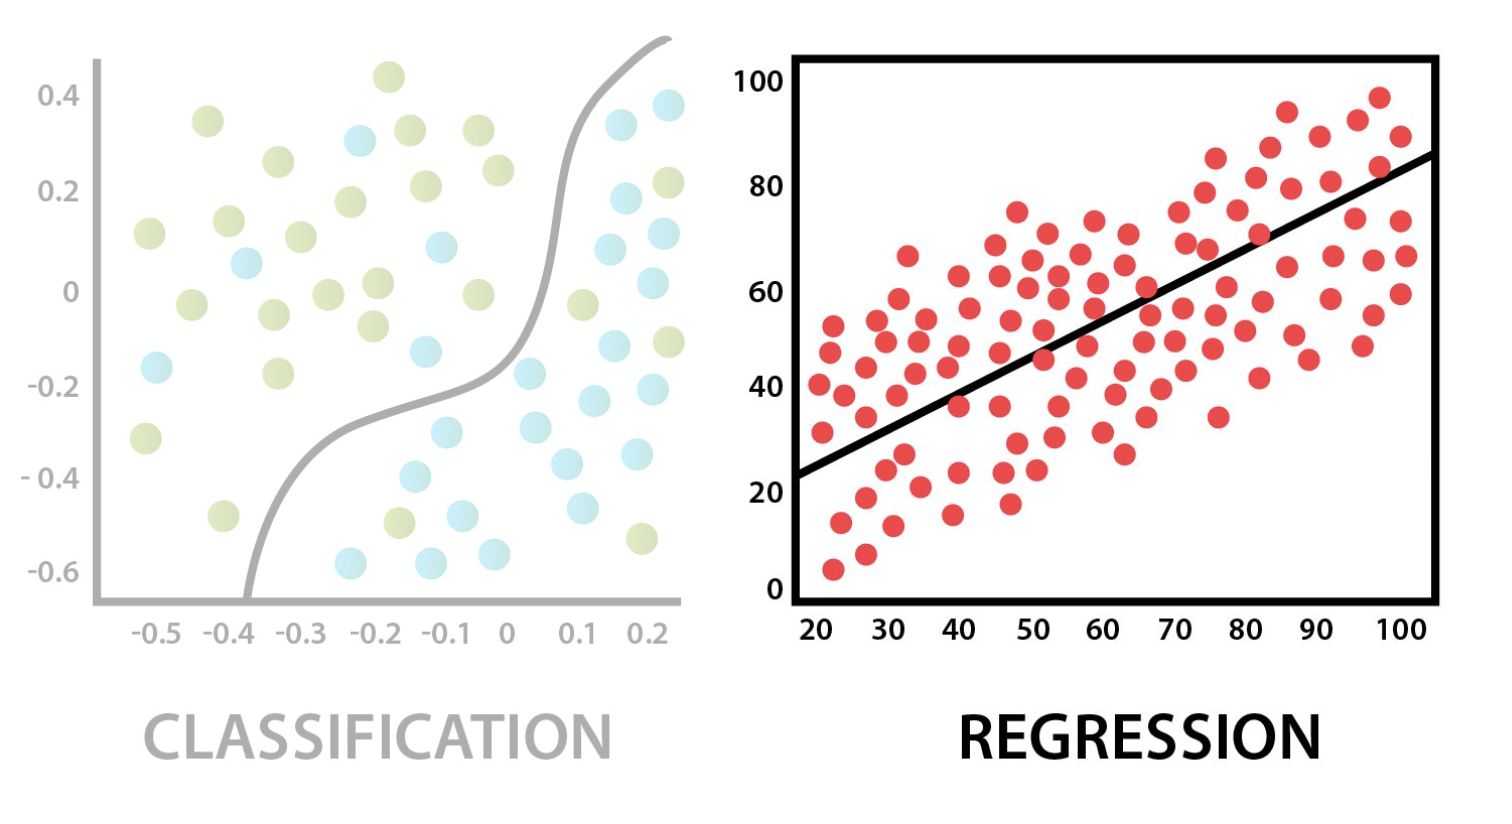

We will use a **Random Forest Regressor**. A random forest combines many decision trees and averages their predictions.

Random Forest models tend to perform well and are generally popular.

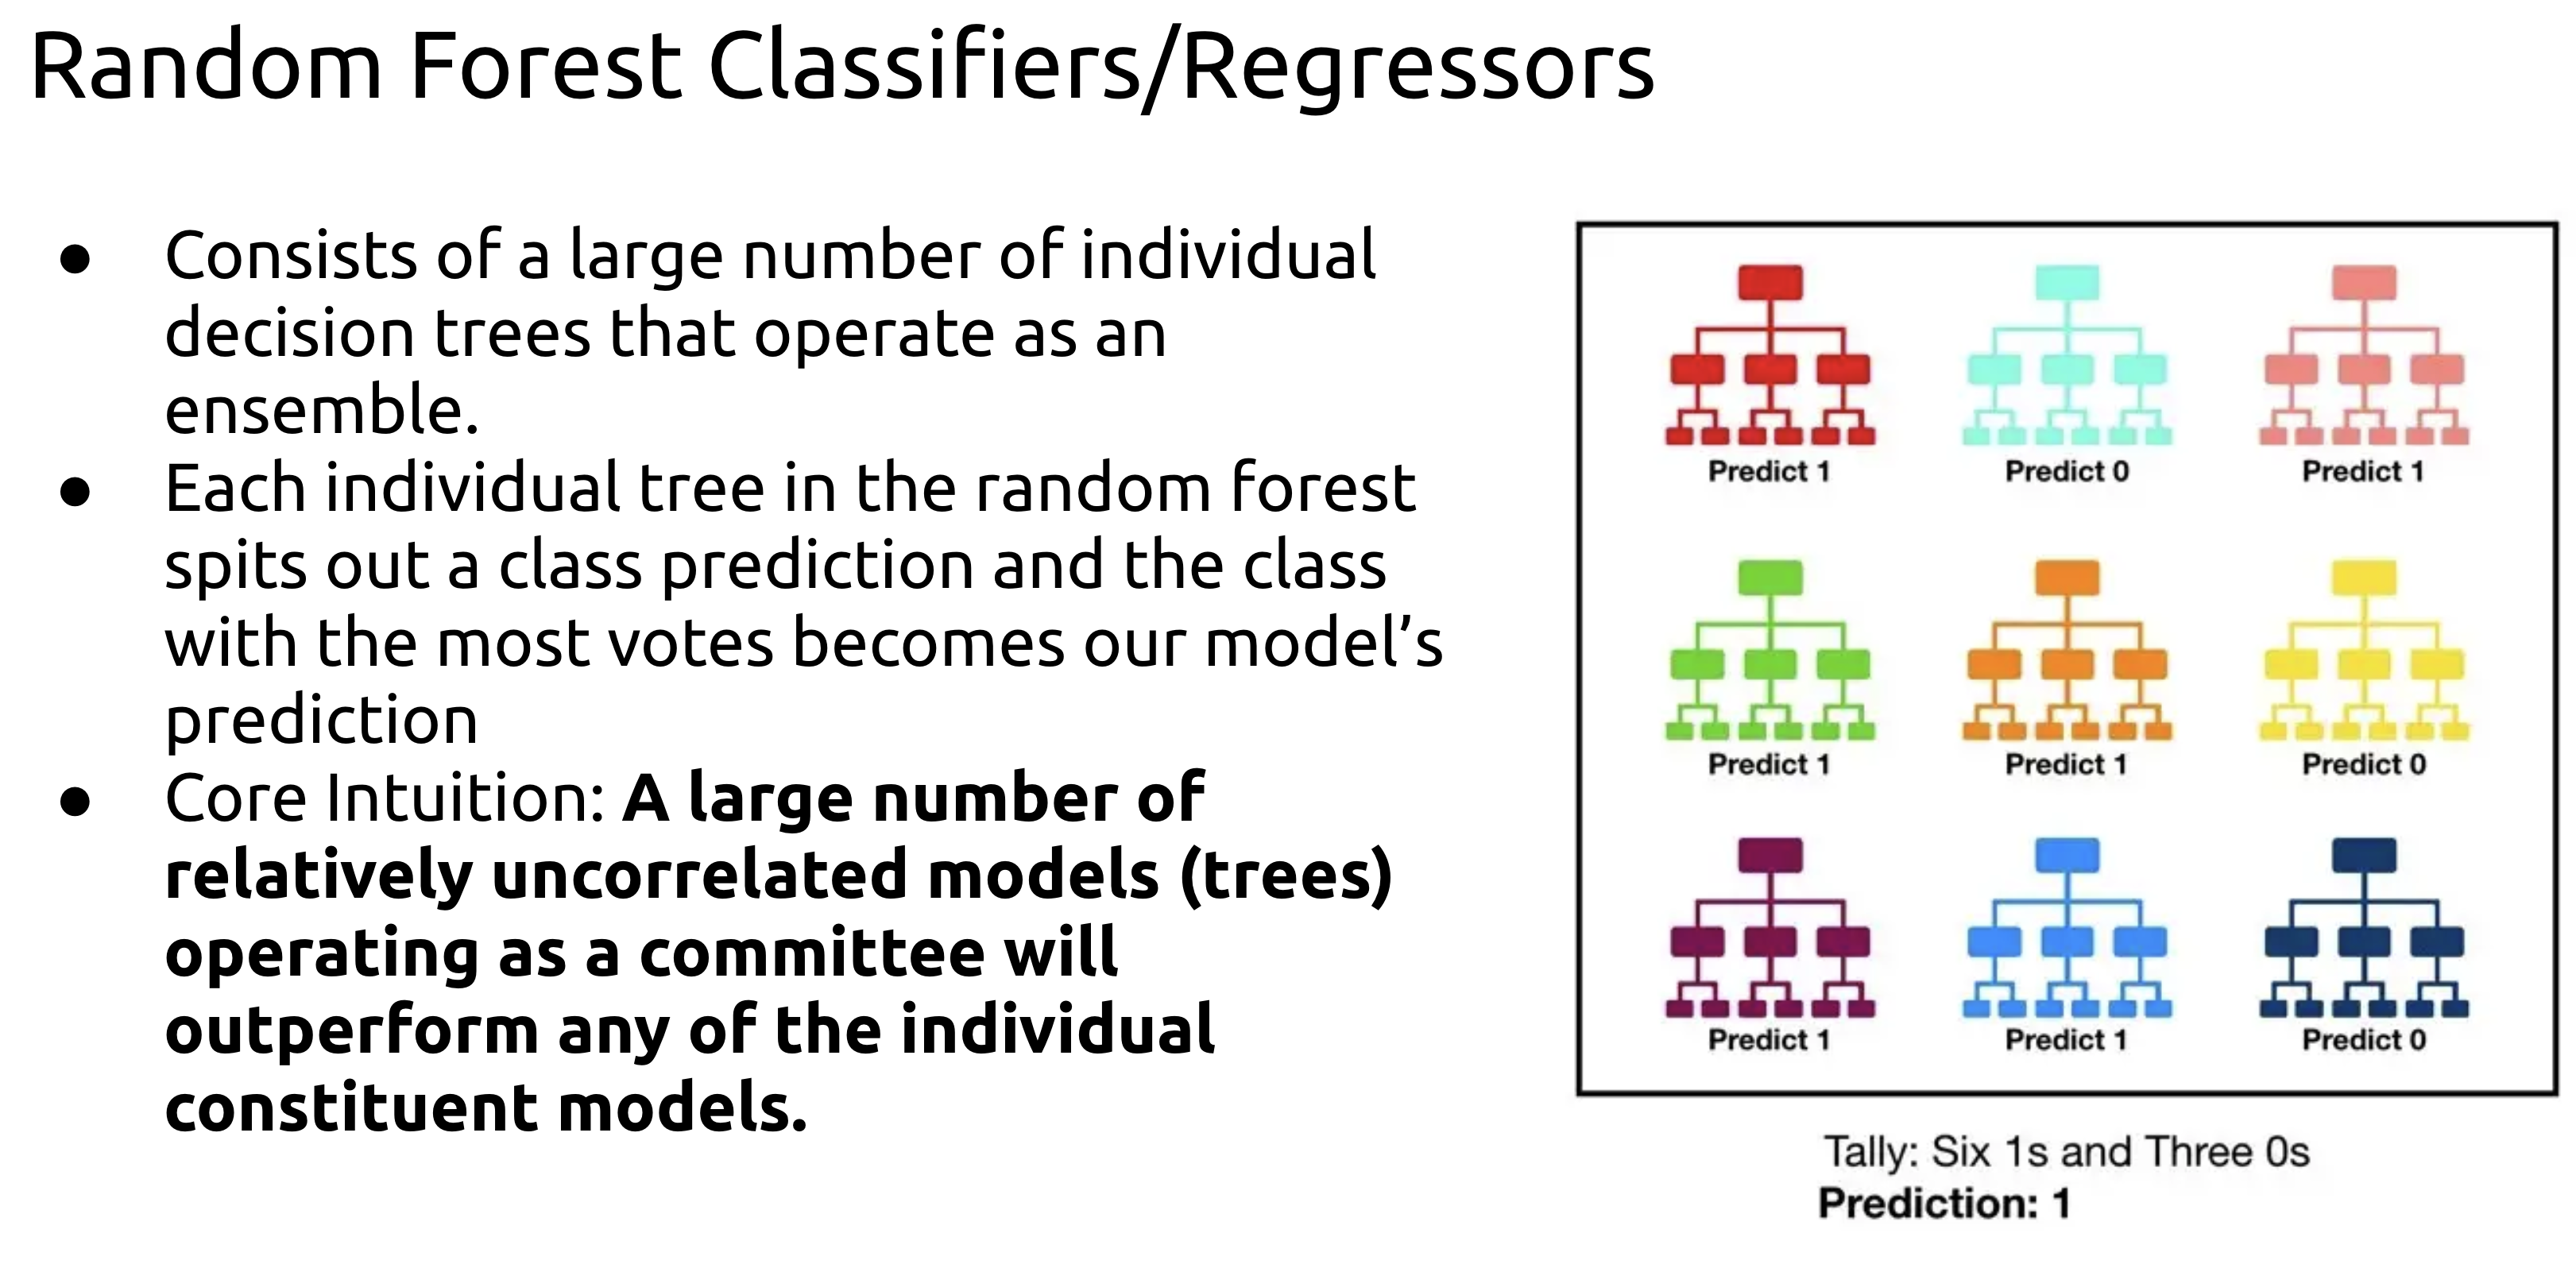

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Convert Hugging Face columns into NumPy arrays for scikit-learn.
X_train_onehot = np.array(split_dataset["train"]["one_hot_features"])
X_test_onehot = np.array(split_dataset["test"]["one_hot_features"])
X_train_vhse = np.array(split_dataset["train"]["vhse_features"])
X_test_vhse = np.array(split_dataset["test"]["vhse_features"])

# Add sequence length as the final feature.
train_lengths = np.array(split_dataset["train"]["sequence_length"]).reshape(-1, 1)
test_lengths = np.array(split_dataset["test"]["sequence_length"]).reshape(-1, 1)
X_train_onehot = np.hstack([X_train_onehot, train_lengths])
X_test_onehot = np.hstack([X_test_onehot, test_lengths])
X_train_vhse = np.hstack([X_train_vhse, train_lengths])
X_test_vhse = np.hstack([X_test_vhse, test_lengths])

y_train = np.array(split_dataset["train"]["stability_score"])
y_test = np.array(split_dataset["test"]["stability_score"])

print("One-hot training shape:", X_train_onehot.shape)
print("VHSE training shape:", X_train_vhse.shape)
print("Target shape:", y_train.shape)

One-hot training shape: (240, 21)
VHSE training shape: (240, 9)
Target shape: (240,)


## Train the one-hot model

`.fit()` is the command that trains a scikit-learn model.

`.predict()` asks the trained model to predict values for new inputs.

In [ ]:
onehot_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

onehot_model.fit(X_train_onehot, y_train)
onehot_predictions = onehot_model.predict(X_test_onehot)

print("Finished training the one-hot model.")

Finished training the one-hot model.


## Evaluate the predictions

We will calculate three common metrics:

* **MAE (Mean Absolute Error):** average size of the prediction error. Lower is better.
* **RMSE (Root Mean Squared Error):** like MAE, but penalizes large errors more strongly. Lower is better.
* **R²:** how much variation in the target is explained by the model. `1` is perfect; `0` is similar to always predicting the mean; negative values are worse than that baseline.

In [ ]:
def regression_metrics(true_values, predictions):
    mae = mean_absolute_error(true_values, predictions)
    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    r2 = r2_score(true_values, predictions)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

onehot_metrics = regression_metrics(y_test, onehot_predictions)
print(onehot_metrics)

{'MAE': 2.0566416666666703, 'RMSE': np.float64(2.5665637944860618), 'R2': 0.21173449534276978}


## Train and evaluate the VHSE model

In [ ]:
vhse_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

vhse_model.fit(X_train_vhse, y_train)
vhse_predictions = vhse_model.predict(X_test_vhse)

vhse_metrics = regression_metrics(y_test, vhse_predictions)
print(vhse_metrics)

{'MAE': 1.9732666666666685, 'RMSE': np.float64(2.5399945754699256), 'R2': 0.22797036230135836}


## Compare the two representations

In [ ]:
results = pd.DataFrame([
    {"Representation": "One-hot composition", **onehot_metrics},
    {"Representation": "VHSE average", **vhse_metrics},
])

results["MAE"] = results["MAE"].round(3)
results["RMSE"] = results["RMSE"].round(3)
results["R2"] = results["R2"].round(3)

display(results)

,Representation,MAE,RMSE,R2
0,One-hot composition,2.057,2.567,0.212
1,VHSE average,1.973,2.540,0.228


<font color=red>📌 **Your turn!** Which representation performed better according to MAE? According to R²? Do all metrics tell the same story?</font>

## Plot predicted values against true values

For a perfect model, every point would lie on the diagonal dashed line.

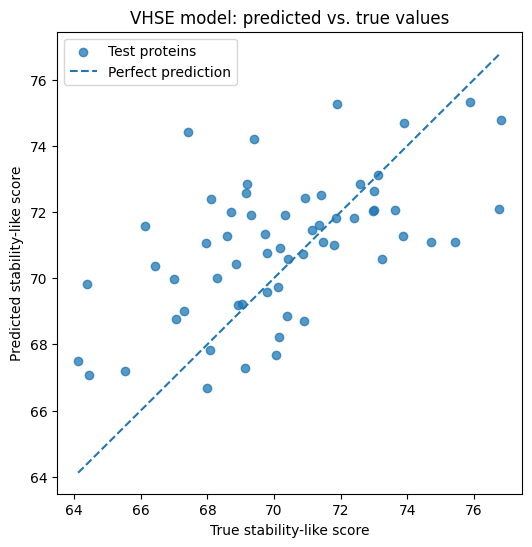

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, vhse_predictions, alpha=0.75, label="Test proteins")

minimum = min(y_test.min(), vhse_predictions.min())
maximum = max(y_test.max(), vhse_predictions.max())
plt.plot([minimum, maximum], [minimum, maximum], "--", label="Perfect prediction")

plt.xlabel("True stability-like score")
plt.ylabel("Predicted stability-like score")
plt.title("VHSE model: predicted vs. true values")
plt.legend()
plt.show()

## Compare against a simple baseline

A model should beat an intentionally simple prediction. Our baseline always predicts the **mean training score**.

In [ ]:
baseline_predictions = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_metrics = regression_metrics(y_test, baseline_predictions)

comparison = pd.DataFrame([
    {"Model": "Always predict training mean", **baseline_metrics},
    {"Model": "One-hot random forest", **onehot_metrics},
    {"Model": "VHSE random forest", **vhse_metrics},
])

display(comparison.round(3))

,Model,MAE,RMSE,R2
0,Always predict training mean,2.329,2.913,-0.016
1,One-hot random forest,2.057,2.567,0.212
2,VHSE random forest,1.973,2.540,0.228


<font color=red>📌 **Your turn!** Why is it important to compare a machine-learning model with a baseline?</font>

# <font color=darkblue>**Part 6.** Interpret, Experiment, and Wrap Up</font>

## Looking at errors

Let us inspect proteins for which the VHSE model made the largest mistakes.

In [ ]:
error_table = pd.DataFrame({
    "protein_id": split_dataset["test"]["protein_id"],
    "sequence_length": split_dataset["test"]["sequence_length"],
    "true_score": y_test,
    "predicted_score": vhse_predictions,
})

error_table["absolute_error"] = (
    error_table["true_score"] - error_table["predicted_score"]
).abs()

error_table = error_table.sort_values("absolute_error", ascending=False)
display(error_table.head(10).round(2))

,protein_id,sequence_length,true_score,predicted_score,absolute_error
0,protein_262,124,67.43,74.42,6.99
56,protein_076,77,66.14,71.58,5.44
54,protein_097,123,64.39,69.82,5.43
14,protein_297,218,69.39,74.21,4.82
29,protein_093,197,76.74,72.09,4.65
12,protein_215,124,75.44,71.09,4.35
43,protein_069,123,68.12,72.40,4.28
53,protein_039,132,66.43,70.35,3.92
24,protein_272,216,69.18,72.84,3.66
21,protein_298,141,74.70,71.10,3.60


## Additional mini-experiments to play around with

Choose one experiment with your group:

1. Change `n_estimators=200` to `20`. Does performance change?
2. Remove the sequence-length feature. Does performance change?
3. Change the train/test split from `test_size=0.20` to `0.30`.
4. Plot one-hot predictions instead of VHSE predictions.
5. Find the average sequence length in the training and test sets.

Be ready to report:

* What did you change?
* What did you predict would happen?
* What actually happened?

# <font color=darkblue>**What You Accomplished**</font>

Today you:

* ran code in Google Colab
* used variables, lists, functions, and NumPy arrays
* loaded and explored a CSV file with pandas
* plotted data with matplotlib
* converted protein sequences into one-hot and VHSE features
* created and split a Hugging Face Dataset
* trained Random Forest regression models
* evaluated predictions using MAE, RMSE, and R²
* compared a model with a baseline

That is quite a lot! Give yourself a hand!

## However -- Caution! A final scientific warning!

Good test performance does not *automatically* mean a model has learned general biological rules. In real protein machine learning, researchers must also consider duplicated proteins, sequence similarity between train and test sets, experimental noise, dataset bias, and whether the evaluation matches the intended use.

# <font color=darkblue>**Optional Challenge:** Predict One New Protein</font>

Enter a sequence containing only the 20 standard amino-acid letters. The cell will encode it and ask both trained models for a prediction.

In [ ]:
new_sequence = "MKTLLILAVAVAASTAGCGAAPVKVKFNADGQY"
new_sequence = new_sequence.strip().upper()

assert is_valid_sequence(new_sequence), "The sequence contains an invalid amino-acid letter."

new_length = np.array([[len(new_sequence)]])
new_onehot = np.hstack([one_hot_composition(new_sequence).reshape(1, -1), new_length])
new_vhse = np.hstack([vhse_average(new_sequence).reshape(1, -1), new_length])

print("Sequence length:", len(new_sequence))
print("One-hot model prediction:", round(onehot_model.predict(new_onehot)[0], 2))
print("VHSE model prediction:", round(vhse_model.predict(new_vhse)[0], 2))
print("Remember: this is an educational synthetic target, not a real stability measurement.")

Sequence length: 33
One-hot model prediction: 70.03
VHSE model prediction: 67.94
Remember: this is an educational synthetic target, not a real stability measurement.


# <font color=darkblue>**If you made it this far and there is still time to work:**</font>

Congratulations!

Explore some other types of regression models:
* [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
* [Support Vector Machine (SVM) Regressor](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html)
* [Gradient Boost Regressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html)

These are all good models to know!

**Try to train and evaluate each of these models on your data as we did above**
You can compare their performance in a dataframe!